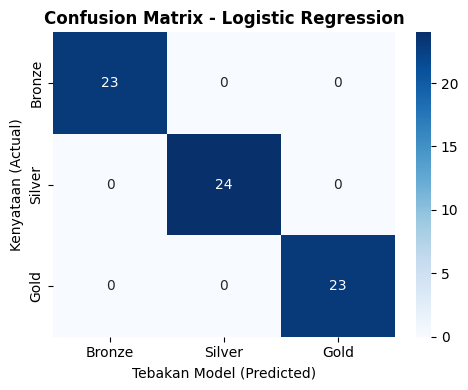


=== EVALUASI MODEL LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

      Bronze       1.00      1.00      1.00        23
      Silver       1.00      1.00      1.00        24
        Gold       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70


PROSES SELESAI DENGAN SUKSES!
1. Grafik Confusion Matrix Biru berhasil disimpan.
2. File biner 'model_logreg.pkl' & 'scaler.pkl' diperbarui.


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# 1. LOAD DATASET BERSIH SINKRON DENGAN VIAN
df_eval = pd.read_csv('E-commerce Customer Behavior Cleaned (1).csv')

# 2. PISAHKAN FITUR DAN TARGET (Target: Membership Type sesuai revisi Ketua)
X_eval = df_eval.drop(columns=['Membership Type'])
y_eval = df_eval['Membership Type']

# 3. BAGI DATA (Train-Test Split) PERSIS DENGAN SETTINGAN VIAN (20% Test)
X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

# 4. STANDARDISASI / SCALING MENGGUNAKAN STANDARDSCALER
scaler_ev = StandardScaler()
X_train_scaled = scaler_ev.fit_transform(X_train_ev)
X_test_scaled = scaler_ev.transform(X_test_ev)

# 5. LATIH ULANG MODEL LOGISTIC REGRESSION SECARA INSTAN
logreg_ev = LogisticRegression(max_iter=1000, random_state=42)
logreg_ev.fit(X_train_scaled, y_train_ev)
y_pred_lr_ev = logreg_ev.predict(X_test_scaled)

# ==========================================================
# PLOT CONFUSION MATRIX TUNGGAL (WARNA BIRU)
# ==========================================================
labels = ['Bronze', 'Silver', 'Gold']

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_ev, y_pred_lr_ev), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.tight_layout()

# Menyimpan hasil visualisasi menjadi file gambar tunggal untuk laporan
plt.savefig('confusion_matrix_logreg.png', dpi=300) 
plt.show()

# ==========================================================
# PRINT CLASSIFICATION REPORT UNTUK BAHAN LAPORAN
# ==========================================================
print("\n=== EVALUASI MODEL LOGISTIC REGRESSION ===")
print(classification_report(y_test_ev, y_pred_lr_ev, target_names=labels))

# ==========================================================
# EXPORT OBJEK MODEL & SCALER (.PKL) UNTUK PRODUKSI STREAMLIT
# ==========================================================
with open('model_logreg.pkl', 'wb') as f:
    pickle.dump(logreg_ev, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_ev, f)

print("\n=======================================================")
print("PROSES SELESAI DENGAN SUKSES!")
print("1. Grafik Confusion Matrix Biru berhasil disimpan.")
print("2. File biner 'model_logreg.pkl' & 'scaler.pkl' diperbarui.")
print("=======================================================")